In [1]:
from sorcha.modules import PPFootprintFilter as fp

import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import numpy as np
import os

### Compare footprint to 

In [3]:
ccdVisits = pd.read_csv( 'CCDVisits.csv' )
ccdVisits

,Unnamed: 0,ccdVisitId,visitID,ra,decl,llcra,llcdec,ulcra,ulcdec,urcra,urcdec,lrcra,lrcdec
0,0,221579000,221579,51.829343,-43.645817,51.680299,-43.761402,51.672269,-43.535598,51.977911,-43.529963,51.987054,-43.755825
1,1,221579001,221579,51.820701,-43.411037,51.672120,-43.526673,51.664306,-43.300765,51.968818,-43.295148,51.977732,-43.521108
2,2,221579002,221579,51.811807,-43.176966,51.663766,-43.292696,51.656007,-43.066714,51.959370,-43.060993,51.968238,-43.287023
3,3,221579003,221579,52.152705,-43.639189,52.004089,-43.755209,51.995006,-43.529348,52.300842,-43.522908,52.311021,-43.748806
4,4,221579004,221579,52.143050,-43.404569,51.994940,-43.520663,51.985992,-43.294702,52.290684,-43.288227,52.300731,-43.514224
...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562,484329184,484329,55.851821,-42.690919,55.636805,-42.682008,55.867686,-42.532852,56.066784,-42.699418,55.835846,-42.848953
563,563,484329185,484329,56.090413,-42.535736,55.876005,-42.527277,56.105576,-42.377650,56.304751,-42.543788,56.075142,-42.693799
564,564,484329186,484329,55.821602,-43.021720,55.605465,-43.012847,55.837635,-42.863726,56.037683,-43.030166,55.805459,-43.179663
565,565,484329187,484329,56.062316,-42.866726,55.846795,-42.858223,56.077775,-42.708700,56.277768,-42.874810,56.046749,-43.024713


In [4]:
fields = pd.read_csv( 'fieldVisits.csv' )
fields

,Unnamed: 0,visit,skyRotation,ra,decl
0,0,221579,87.141066,54.031386,-42.642097
1,0,185782,359.398591,53.027594,-42.578728
2,0,484329,140.151064,53.882280,-42.079797


In [6]:
camera = fp.Footprint( 'detectors_corners.csv' )

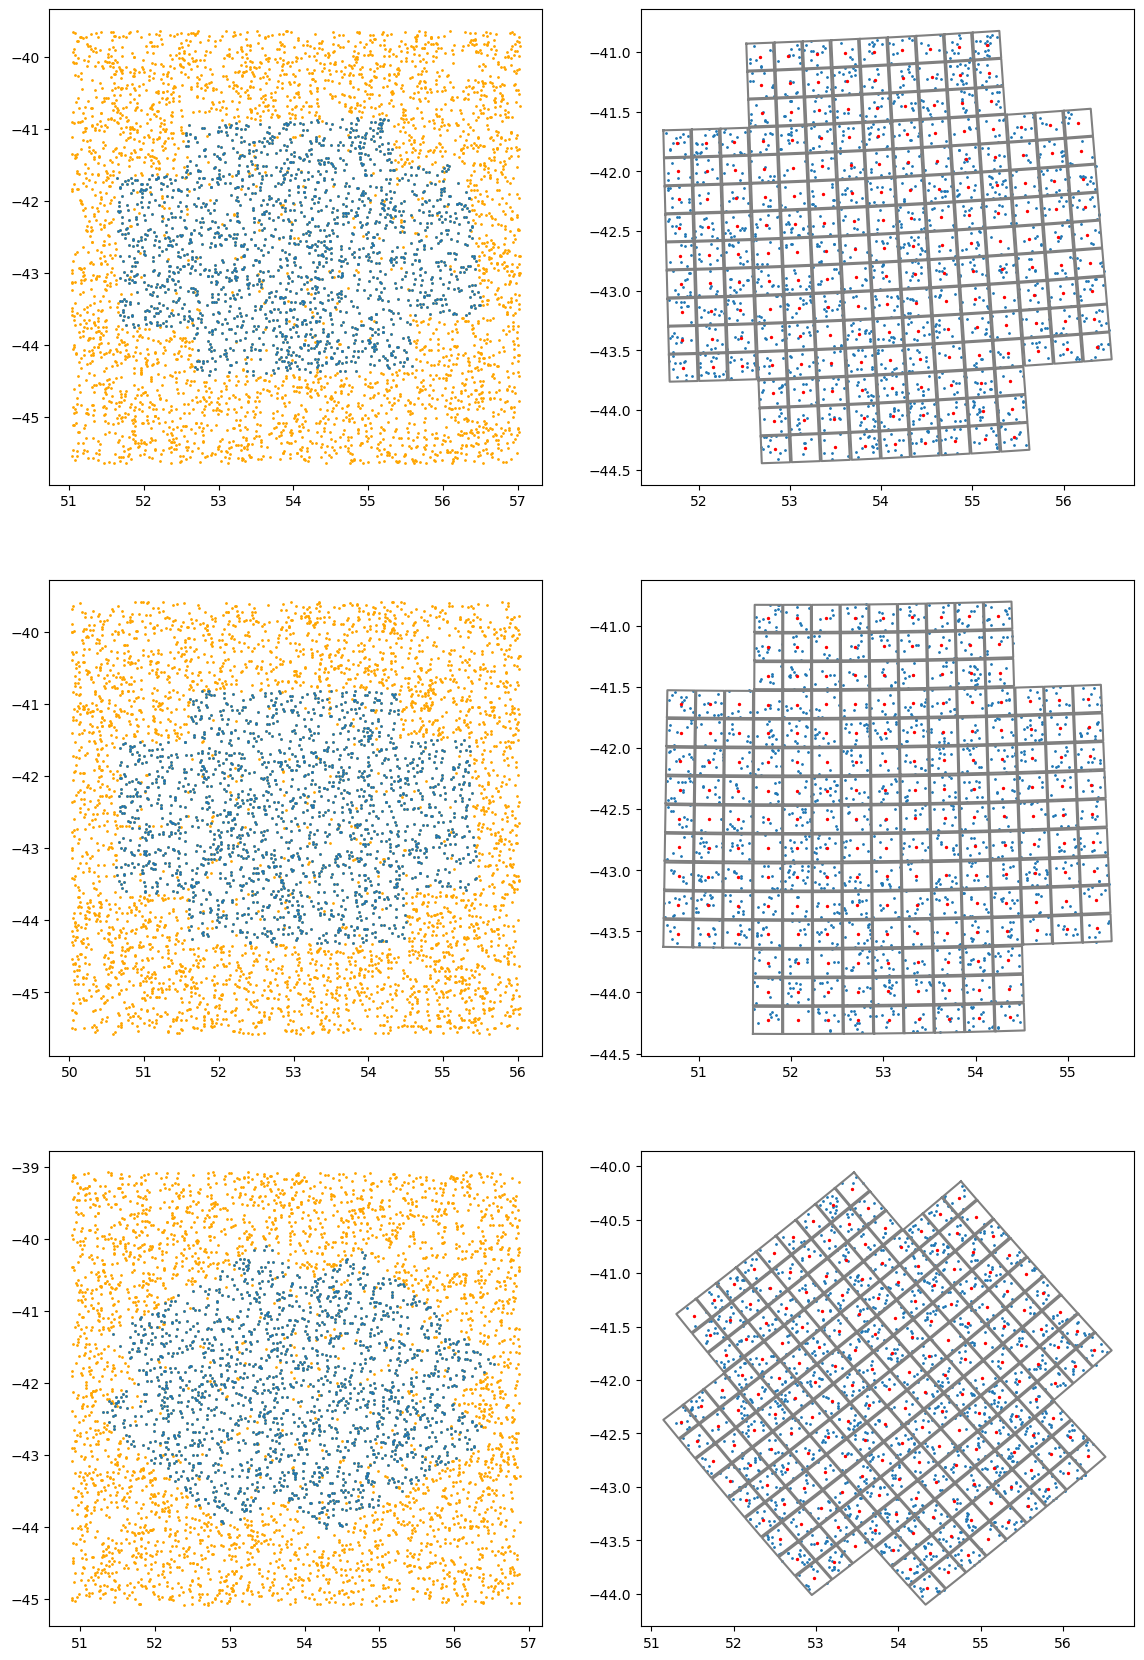

In [44]:
# around each field, distribute points (detections)
N = 5000
fig, ax = plt.subplots( 3, 2, figsize=(14, 21) )

for i, row in fields.iterrows():
    x = np.random.rand(N) * 2 - 1 # -1, 1
    y = np.random.rand(N) * 2 - 1

    ra = row['ra'] + x*3.0
    dec = row['decl'] + y*3.0

    df = pd.DataFrame()
    df['ra'] = ra
    df['decl'] = dec
    df['fieldRA'] = row['ra']
    df['fieldDec'] = row['decl']
    df['rotSkyPos'] = row['skyRotation']
    df['FieldID'] = row['visit']

    mask, _ = camera.applyFootprint( df, ra_name='ra', dec_name='decl' )

    ax[i, 0].scatter( ra, dec, s=1.0, color='orange' )
    ax[i, 0].scatter( ra[mask], dec[mask], s=1.0)
    ax[i, 1].scatter( ra[mask], dec[mask], s=1.0)

    ccds = ccdVisits[ ccdVisits['visitID'] == row['visit'] ]
    ax[i, 1].scatter( ccds['ra'], ccds['decl'], s=2.0, color='red' )

    for j, ccd in ccds.iterrows():
        v_ra   = ccd[[ 'ulcra', 'llcra', 'lrcra', 'urcra', 'ulcra' ]]
        v_decl = ccd[[ 'ulcdec', 'llcdec', 'lrcdec', 'urcdec', 'ulcdec' ]]

        ax[i, 1].plot( v_ra, v_decl, color='gray' )


# filter through footprint
# plot points, ccd corners

In [41]:
ccds

,Unnamed: 0,ccdVisitId,visitID,ra,decl,llcra,llcdec,ulcra,ulcdec,urcra,urcdec,lrcra,lrcdec
0,0,221579000,221579,51.829343,-43.645817,51.680299,-43.761402,51.672269,-43.535598,51.977911,-43.529963,51.987054,-43.755825
1,1,221579001,221579,51.820701,-43.411037,51.672120,-43.526673,51.664306,-43.300765,51.968818,-43.295148,51.977732,-43.521108
2,2,221579002,221579,51.811807,-43.176966,51.663766,-43.292696,51.656007,-43.066714,51.959370,-43.060993,51.968238,-43.287023
3,3,221579003,221579,52.152705,-43.639189,52.004089,-43.755209,51.995006,-43.529348,52.300842,-43.522908,52.311021,-43.748806
4,4,221579004,221579,52.143050,-43.404569,51.994940,-43.520663,51.985992,-43.294702,52.290684,-43.288227,52.300731,-43.514224
...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,184,221579184,221579,55.874066,-41.848834,55.736525,-41.969603,55.714496,-41.744086,56.011004,-41.727964,56.034109,-41.953364
185,185,221579185,221579,55.850523,-41.615150,55.713509,-41.735829,55.691543,-41.510409,55.986928,-41.494374,56.009975,-41.719673
186,186,221579186,221579,56.211631,-42.065442,56.074391,-42.186654,56.051038,-41.961197,56.348260,-41.944124,56.372674,-42.169448
187,187,221579187,221579,56.187364,-41.831453,56.050558,-41.952524,56.027455,-41.727127,56.323569,-41.710287,56.347741,-41.935546
